In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("/content/South Asian Wireless Telecom Operator (SATO 2015).csv")

print(f" dataframe head : {df.head()}")
print(f" dataframe shape : {df.shape}")
print(f" dataframe info : {df.info()}")



 dataframe head :    network_age  Aggregate_Total_Rev  Aggregate_SMS_Rev  Aggregate_Data_Rev  \
0         1914            1592.7200              23.26                 2.5   
1         2073            1404.1496             174.45                27.5   
2         3139              85.5504              14.34                 5.0   
3          139            2315.2292              19.25                52.5   
4          139             227.8620               2.95                42.5   

   Aggregate_Data_Vol  Aggregate_Calls  Aggregate_ONNET_REV  \
0        1.161130e+01              375                25523   
1        2.531725e+03              389                14584   
2        2.913306e+04               15                  477   
3        2.674413e+05              636                50316   
4        1.461621e+06               17                 2568   

   Aggregate_OFFNET_REV  Aggregate_complaint_count aug_user_type  \
0                 99000                          1            2G  

In [108]:
df['Class'] = LabelEncoder().fit_transform(df['Class'])
y = df['Class']
x = df.drop(['Class'], axis = 1)



imputer = SimpleImputer(strategy='most_frequent')
x = pd.DataFrame(imputer.fit_transform(x), columns=x.columns)

for col in x.columns:
  if x[col].dtype == 'object':
    x[col] = LabelEncoder().fit_transform(x[col])
  else:
    x[col] = StandardScaler().fit_transform(x[col].values.reshape(-1, 1))


In [109]:
y.value_counts()

,count
Class,
1,1000
0,1000


In [110]:
smote = SMOTE(random_state=42)
x, y= smote.fit_resample(x, y)

In [111]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1600, 13)
(400, 13)
(1600,)
(400,)


In [104]:
y.value_counts()

,count
Class,
Churned,1000
Active,1000


Accuracy: 0.7225
Precision: 0.6952380952380952
Recall: 0.7564766839378239
F1 Score: 0.7245657568238213


Text(0.5, 1.0, 'Confusion Matrix')

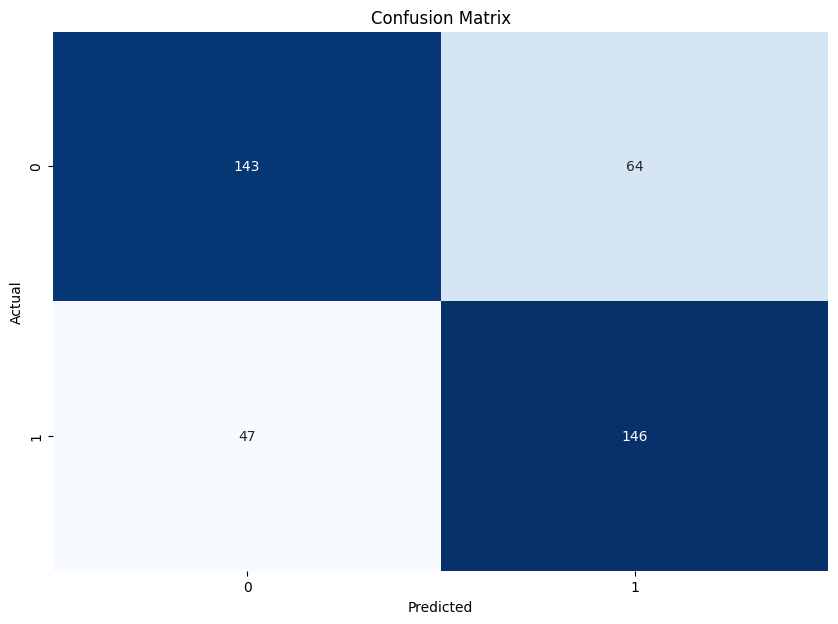

In [114]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize XGBoost Regressor model
xgb = xgb.XGBClassifier(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    n_jobs=-1)

# Train the model
xgb.fit(x_train, y_train)

# Make predictions on the test set
y_pred = xgb.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# Plotting actual vs. predicted values
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

In [115]:
import joblib

joblib.dump(xgb_model, "xg boost model")
print("Model saved as xg boost ")

Model saved as xg boost 
